# BrushCue Example: Coquette Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/coquette_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/coquette-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA

'


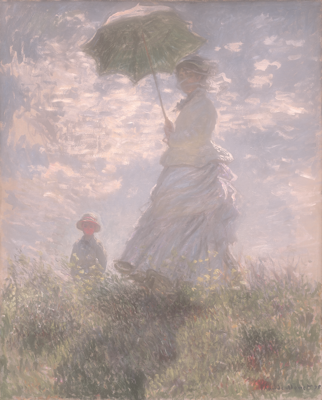

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
graded = input_image.color_transformer_shader(
    "let c = length(input.yz);\nlet h = atan2(input.z, input.y);\nlet colorful = smoothstep(0.01, 0.05, c);\nlet pink = band(h, -0.2, 1.3) * colorful;\nlet skin = band(h, 0.9, 0.7);\nlet keep = max(pink, 0.6 * skin);\nlet h2 = h - 0.08 * pink * amount;\nlet c2 = c * mix(1.0, mix(0.3, 1.05, keep), amount);\nvar l = pow(max(input.x, 0.0), 1.0 - 0.26 * amount);\nl = mix(l, 0.15 + l * 0.84, amount);\nlet hi = smoothstep(0.55, 1.0, l);\nlet a = c2 * cos(h2) + (0.014 + 0.016 * hi) * amount;\nlet b = c2 * sin(h2) + (0.008 * (1.0 - keep) + 0.002 * hi) * amount;\nlet rolloff = 1.0 - smoothstep(0.92, 1.05, l);\nreturn vec4<f32>(clamp(l, 0.0, 1.0), a * rolloff, b * rolloff, input.w);",
    "fn band(h: f32, center: f32, width: f32) -> f32 {\n  let d = abs(atan2(sin(h - center), cos(h - center)));\n  return 1.0 - smoothstep(width * 0.5, width, d);\n}",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)
bounds = input_image.bounds()
diffusion = graded.gaussian_blur((bounds.width() * 0.015)).opacity_scales(
    (0.6 * strength)
)
glamour = diffusion.blend_max(graded, bc.Transform2.identity())
graph = glamour.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
